In [71]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats
import xarray as xr

from mcs_prime import mcs_prime_config_util as cu

In [3]:
datadir = cu.PATHS['datadir']
simdir = datadir / 'UM_sims'

EXPTS = {
    # 'ctrl': 'u-di727',    
    'vanillaMCSP': 'u-di728',    
    'stochMCSP': 'u-dg135',
}

In [ ]:
expt_cf = {}
for expt, suite in EXPTS.items():
    cf_path = simdir / f'{suite}/processed/{expt}/engla_pa.mcsp_calling_freq.nc'
    expt_cf[expt] = xr.load_dataarray(cf_path)

In [64]:
expt_precip = {}
for expt, suite in EXPTS.items():
    precip_path = simdir / f'{suite}/processed/{expt}/engla_pa.precip.nc'
    expt_precip[expt] = xr.load_dataarray(precip_path)
    expt_precip[expt].values *= 3600
    expt_precip[expt].attrs['units'] = 'mm h-1'


In [5]:
cfmean_vanillaMCSP = expt_cf['vanillaMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
cfmean_stochMCSP = expt_cf['stochMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
cfmeans = {
    'vanillaMCSP': cfmean_vanillaMCSP,
    'stochMCSP': cfmean_stochMCSP,
}

In [66]:
precipmean_vanillaMCSP = expt_precip['vanillaMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
precipmean_stochMCSP = expt_precip['stochMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
precipmeans = {
    'vanillaMCSP': precipmean_vanillaMCSP,
    'stochMCSP': precipmean_stochMCSP,
}

271.0


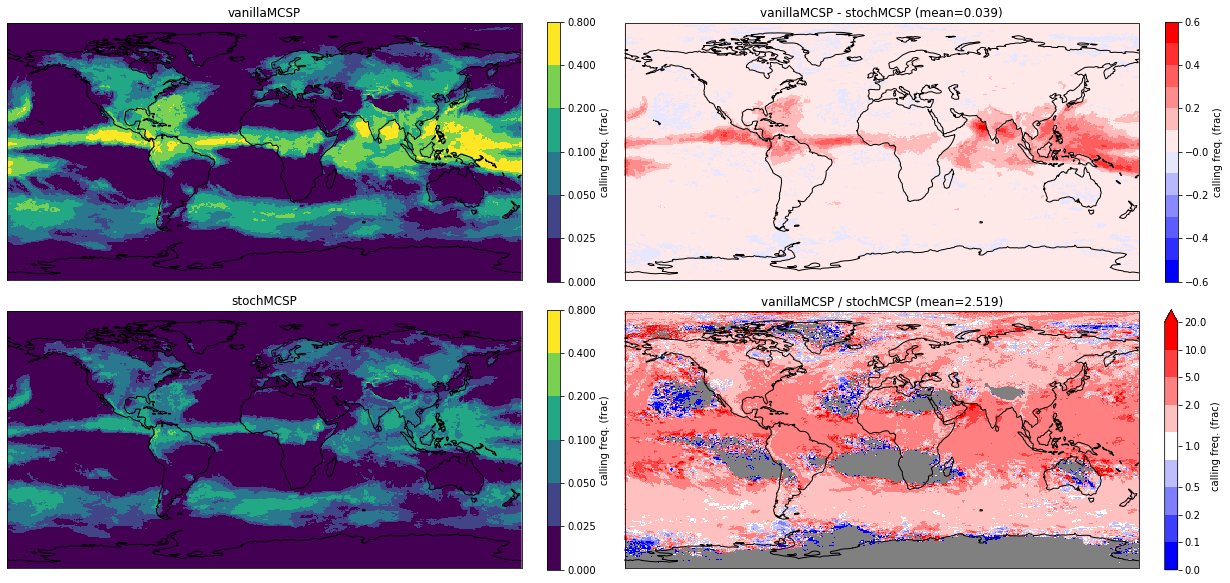

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(17, 8), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
cfmax = max(
    cfmean_vanillaMCSP.values.max(), 
    cfmean_stochMCSP.values.max()
)
for ax, expt in zip(axes[:, 0], expt_cf):
    
    cfmean = cfmeans[expt]
    ax.set_title(expt)
    ax.coastlines()
    #bounds = np.arange(0, np.round(cfmax + 0.1, 1), 0.05)
    bounds = [0, 0.025, 0.05, 0.1, 0.2, 0.4, 0.8] 
    cmap = mpl.cm.viridis
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
    im = ax.pcolormesh(cfmean.longitude, cfmean.latitude, cfmean, norm=norm, cmap=cmap)
    plt.colorbar(im, ax=ax, label='calling freq. (frac)')

for ax, method in zip(axes[:, 1], ['diff', 'frac']):
    ax.coastlines()
    if method == 'diff':
        cfdata = cfmean_vanillaMCSP - cfmean_stochMCSP
        ax.set_title(f'vanillaMCSP - stochMCSP (mean={np.nanmean(cfdata):.3f})')
        absmax = np.round(np.abs(cfdata.values).max(), 1)
        bounds = np.arange(-absmax, absmax, 0.1)
        cmap = mpl.cm.bwr
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
        im = ax.pcolormesh(cfdata.longitude, cfdata.latitude, cfdata, norm=norm, cmap=cmap)
        plt.colorbar(im, ax=ax, label='calling freq. (frac)')
    elif method == 'frac':
        cfdata = np.ma.masked_invalid(cfmean_vanillaMCSP / cfmean_stochMCSP)
        cfdata_mean = cfdata.mean()
        ax.set_title(f'vanillaMCSP / stochMCSP (mean={cfdata_mean:.3f})')
        # cf99 = np.nanpercentile(cfdata.values, 99)
        print(np.max(cfdata))
        bounds = [0, 0.1, 0.2, 0.5, 0.9, 1.1, 2, 5, 10, 20]
        cmap = mpl.cm.bwr
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
        ax.set_facecolor('grey')
        im = ax.pcolormesh(cfmean_vanillaMCSP.longitude, cfmean_vanillaMCSP.latitude, cfdata, norm=norm, cmap=cmap)
        plt.colorbar(im, ax=ax, label='calling freq. (frac)', extend='max', ticks=[0, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20])

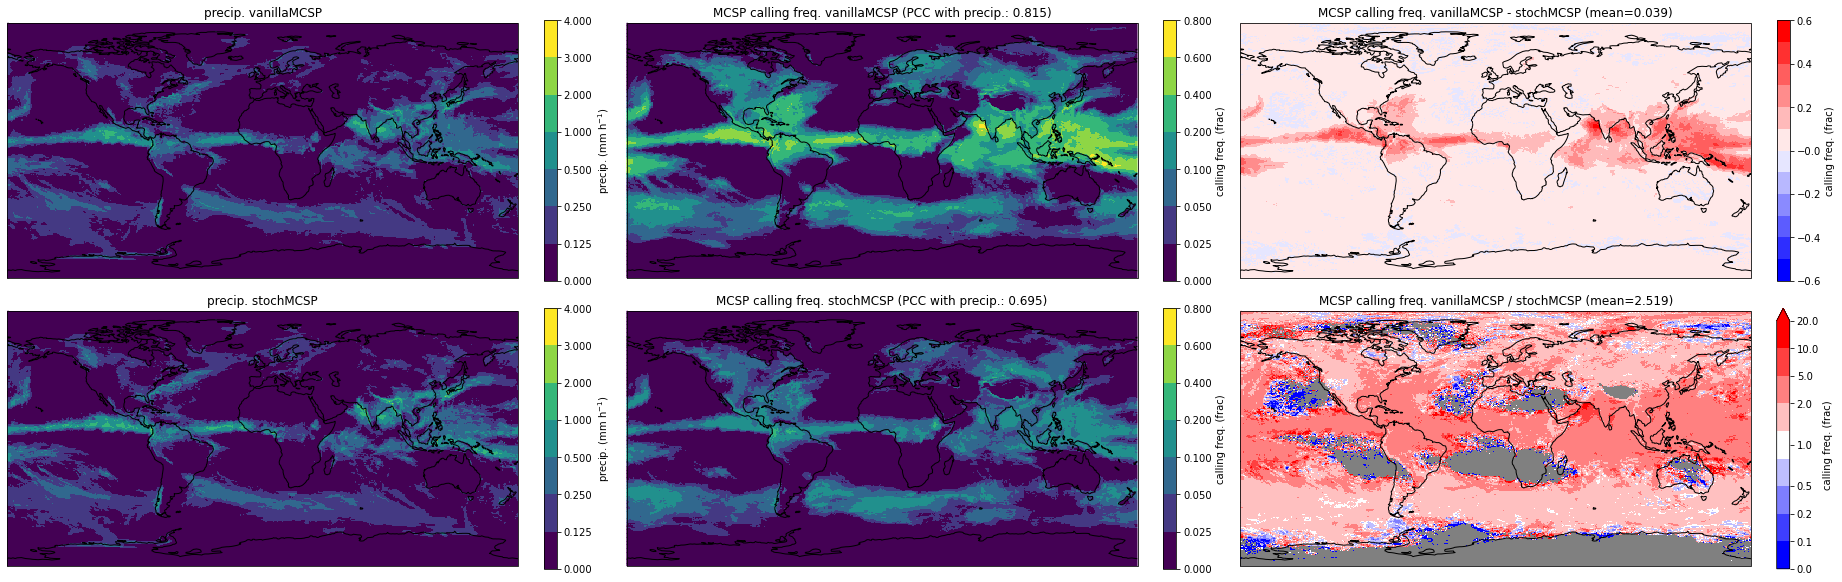

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(25.5, 8), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

for ax, expt in zip(axes[:, 0], expt_precip):
    
    precipmean = precipmeans[expt]
    ax.set_title(f'precip. {expt}')
    ax.coastlines()
    #bounds = np.arange(0, np.round(cfmax + 0.1, 1), 0.05)
    bounds = [0, 0.125, 0.25, 0.5, 1, 2, 3, 4] 
    cmap = mpl.cm.viridis
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
    im = ax.pcolormesh(precipmean.longitude, precipmean.latitude, precipmean, norm=norm, cmap=cmap)
    plt.colorbar(im, ax=ax, label='precip. (mm h$^{-1}$)')


for ax, expt in zip(axes[:, 1], expt_cf):
    
    cfmean = cfmeans[expt]
    precipmean = precipmeans[expt]
    pcc = scipy.stats.pearsonr(cfmean.values.flatten(), precipmean.values.flatten())[0]
    ax.set_title(f'MCSP calling freq. {expt} (PCC with precip.: {pcc:.3f})')
    ax.coastlines()
    #bounds = np.arange(0, np.round(cfmax + 0.1, 1), 0.05)
    bounds = [0, 0.025, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8] 
    cmap = mpl.cm.viridis
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
    im = ax.pcolormesh(cfmean.longitude, cfmean.latitude, cfmean, norm=norm, cmap=cmap)
    plt.colorbar(im, ax=ax, label='calling freq. (frac)')

for ax, method in zip(axes[:, 2], ['diff', 'frac']):
    ax.coastlines()
    if method == 'diff':
        cfdata = cfmean_vanillaMCSP - cfmean_stochMCSP
        ax.set_title(f'MCSP calling freq. vanillaMCSP - stochMCSP (mean={np.nanmean(cfdata):.3f})')
        absmax = np.round(np.abs(cfdata.values).max(), 1)
        bounds = np.arange(-absmax, absmax, 0.1)
        cmap = mpl.cm.bwr
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
        im = ax.pcolormesh(cfdata.longitude, cfdata.latitude, cfdata, norm=norm, cmap=cmap)
        plt.colorbar(im, ax=ax, label='calling freq. (frac)')
    elif method == 'frac':
        cfdata = np.ma.masked_invalid(cfmean_vanillaMCSP / cfmean_stochMCSP)
        cfdata_mean = cfdata.mean()
        ax.set_title(f'MCSP calling freq. vanillaMCSP / stochMCSP (mean={cfdata_mean:.3f})')
        # cf99 = np.nanpercentile(cfdata.values, 99)
        # print(np.max(cfdata))
        bounds = [0, 0.1, 0.2, 0.5, 0.9, 1.1, 2, 5, 10, 20]
        cmap = mpl.cm.bwr
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
        ax.set_facecolor('grey')
        im = ax.pcolormesh(cfmean_vanillaMCSP.longitude, cfmean_vanillaMCSP.latitude, cfdata, norm=norm, cmap=cmap)
        plt.colorbar(im, ax=ax, label='calling freq. (frac)', extend='max', ticks=[0, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20])

In [33]:
np.arange(0, np.round(0.7434 + 0.2, 1), 0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

In [56]:
# Makes it look like there are 8 timesteps an hour, or dt=7.5 mins.
vals, counts = np.unique(expt_cf['vanillaMCSP'].values, return_counts=True)
vals, counts

(array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   ],
       dtype=float32),
 array([295924864,   6739793,   7323789,   2732223,   2484911,   2346961,
          4580384,   2608868,  11181407]))

In [33]:
# However, 
# mamue@xcslc0 /projects/mcsprime/mamue/cylc-run/u-dg135/work/20200701T0000Z/engl_um_fcst_em0_cr0 $ grep steps *
# ATMOSCNTL:steps_per_periodim=240,
# And this is backed up by looking in pe_output, which shows dt=6 mins.
# Why the discrepancy?

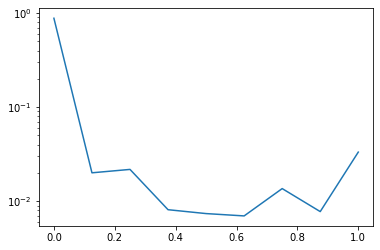

In [58]:
fig, ax = plt.subplots()
ax.plot(vals, counts / counts.sum())
ax.set_yscale('log')